In [1]:
from T4setup import *
from plot_functions import *
from functions import *
import random 
random.seed(10)
ped_str = ['LR', 'RL', 'AP', 'PA']
t2w_fn = 'subj2_Philips_s0_T2W_fatsat_midsag_acpc.nii'

FigureFolder = 'C:/Users/thaias/OneDrive - National Institutes of Health/Figures'
DataFolder = 'C:/Users/thaias/OneDrive - National Institutes of Health/T2W_ghost_simulation/SimulationData'
s_id = 90
myPlot = PlotSettup(block_show=False, fig_size=(7,5), save_folder=FigureFolder, overwrite_all=False)
mySubject = ScanSetup(2,0)

mask = np.fliplr(nib.load('mask_mask.nii').get_fdata()[..., s_id].T)
data = np.fliplr(nib.load(t2w_fn).get_fdata()[...,s_id].T)*mask


 SAVING image to C:/Users/thaias/OneDrive - National Institutes of Health/Figures\corrected_images.png
 [0.05746713 0.04797567 0.00989284 0.00879096]


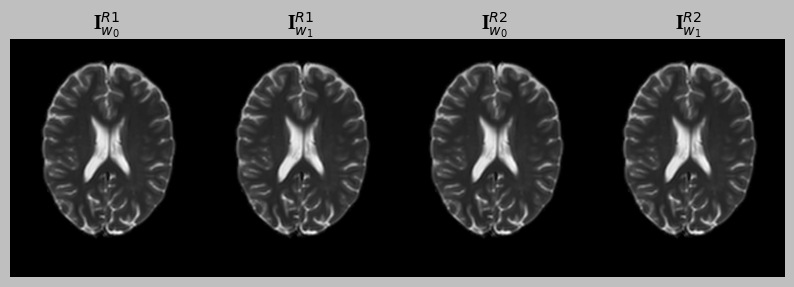

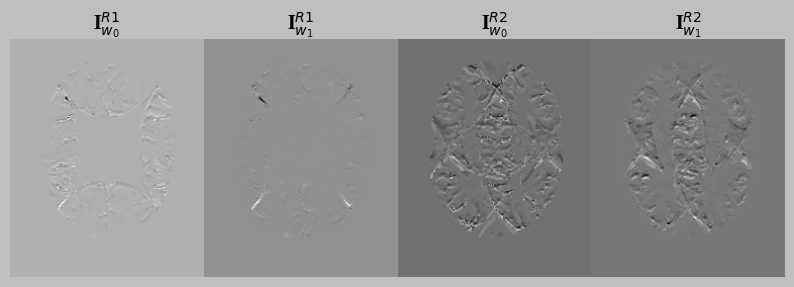

In [15]:
corr1_N2_fn = os.path.join(DataFolder, 'ImageCorrect1_N2.nii')
corr2_N2_fn = os.path.join(DataFolder, 'ImageCorrect2_N2.nii')
corr1_N4_fn = os.path.join(DataFolder, 'ImageCorrect1_N4.nii')
corr2_N4_fn = os.path.join(DataFolder, 'ImageCorrect2_N4.nii')

data_corr1_N2 = np.fliplr(nib.load(corr1_N2_fn).get_fdata()[...,s_id].T) * mask
data_corr2_N2 = np.fliplr(nib.load(corr2_N2_fn).get_fdata()[...,s_id].T) * mask
data_corr1_N4 = np.fliplr(nib.load(corr1_N4_fn).get_fdata()[...,s_id].T) * mask 
data_corr2_N4 = np.fliplr(nib.load(corr2_N4_fn).get_fdata()[...,s_id].T) * mask

corr_arr = np.squeeze(np.stack([data_corr1_N2,data_corr2_N2,data_corr1_N4,data_corr2_N4], axis = -1))
myPlot.fig_size = (10,7)
f = myPlot.show_imgs_array(corr_arr,
                         ['I$_{w_0}^{R1}$','I$_{w_1}^{R1}$', 'I$_{w_0}^{R2}$', 'I$_{w_1}^{R2}$'])
myPlot.save_figure(f, 'corrected_images')

f = myPlot.show_imgs_array(corr_arr-data[...,np.newaxis],
                         ['I$_{w_0}^{R1}$','I$_{w_1}^{R1}$', 'I$_{w_0}^{R2}$', 'I$_{w_1}^{R2}$'])
prt_cyan(np.max(np.abs(normalize_arr(corr_arr)-normalize_arr(data[...,np.newaxis])), axis = (0,1)))

In [3]:
print(mySubject.compare_ssim_2D(corr_arr, data , normalize=0))
print(mySubject.compare_mse_2D(corr_arr, data, normalize=1))
def mse_by_me(data1,data2):
    data_delta = np.mean((data1 - data2)**2)
    return data_delta

print(mse_by_me(corr_arr[...,0], data ))

[0.99961445 0.99987791 0.99990993 0.99994949]
[2.14976982e-06 1.42855644e-06 5.14220860e-07 2.88866296e-07]
3422.4145424714966


In [4]:
APLR_N2_fn = os.path.join(DataFolder, 'simulation_APLR_N2.nii')
APLR_N4_fn = os.path.join(DataFolder, 'simulation_APLR_N4.nii')
mask_0 = nib.load('mask_mask.nii').get_fdata()
data_0 = nib.load(t2w_fn).get_fdata() *mask_0
APLR_N2 = nib.load(APLR_N2_fn).get_fdata() *mask_0[..., np.newaxis]
APLR_N4 = nib.load(APLR_N4_fn).get_fdata() *mask_0[..., np.newaxis]



In [5]:
APLR_N2_sid = np.squeeze(np.stack([np.fliplr(APLR_N2[...,s_id, i].T) for i in range(4)], axis = -1))
APLR_N4_sid = np.squeeze(np.stack([np.fliplr(APLR_N4[...,s_id, i].T) for i in range(4)], axis = -1))

APLR_N2_sid.shape

(236, 192, 4)

[0.99906489 0.9926384  0.98578788 0.99811421]
[1.72246764e-06 2.65362204e-05 7.42057447e-05 5.80982372e-06]
[0.99958944 0.99906708 0.99724571 0.99957425]
[2.28622806e-07 2.75025754e-06 1.54354371e-05 1.21244690e-06]


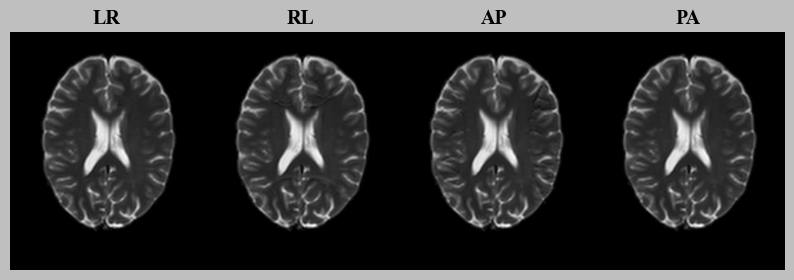

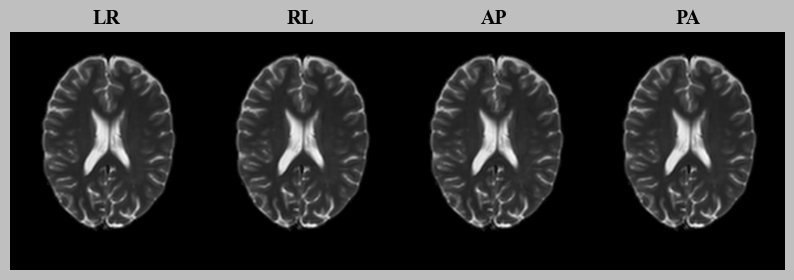

In [6]:

f = myPlot.show_imgs_array(APLR_N2_sid, ped_str)
f = myPlot.show_imgs_array(APLR_N4_sid, ped_str)
print(mySubject.compare_ssim_2D(APLR_N2_sid, data, normalize=1))
print(mySubject.compare_mse_2D(APLR_N2_sid, data, normalize=1))

print(mySubject.compare_ssim_2D(APLR_N4_sid, data, normalize=1))
print(mySubject.compare_mse_2D(APLR_N4_sid, data, normalize=1))

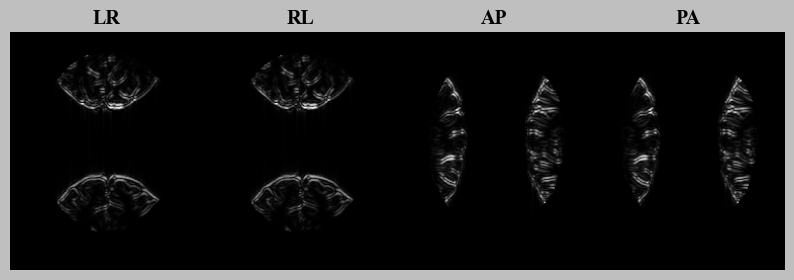

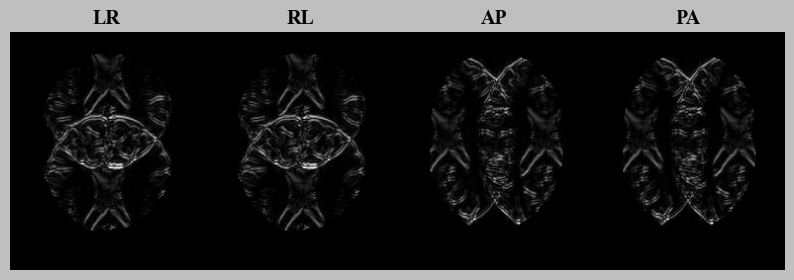

In [7]:
plt.style.use('fast')

f = myPlot.show_imgs_array(np.abs(APLR_N2_sid-data[...,np.newaxis]), ped_str)
f = myPlot.show_imgs_array(np.abs(APLR_N4_sid-data[...,np.newaxis]), ped_str)


In [26]:
# Comment out for debugging.
# for s_id  in range(data_0.shape[-1]):
#     constant_phis = [random.random() for i in range(4)]
#     mse_val = mySubject.compare_mse_2D(APLR_N2[..., s_id,:], data_0[...,s_id])
#     ssim_val = mySubject.compare_ssim_2D(APLR_N2[..., s_id,:], data_0[...,s_id])
#     prt_yellow('sliceID:{} {}'.format(s_id, constant_phis))
#     print(mse_val)
#     print(ssim_val)
    

In [ ]:
# Load the stats 
df_n2_fn = os.path.join(DataFolder, 'T2W_ssim_N2_normalizeFalse.csv')
df_n4_fn = os.path.join(DataFolder, 'T2W_ssim_N4_normalizeFalse.csv')